# Image Classification Assignment [RE-604 Computer Vision]
**Midterm Project — Computer Vision**

#### Aldon Zufar Putra Twyn [4222301042]
#### Robotics - B Class

**Pipeline:**
1. Dataset Preparation (EMNIST Letters, 2600 samples)
2. HOG Feature Extraction
3. SVM Classification with Grid Search
4. Evaluation (Accuracy, Precision, Recall, F1-Score)

In [1]:
!pip install scikit-image scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from skimage.feature import hog
from skimage import exposure

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

import time

print("All libraries imported successfully!")

All libraries imported successfully!


## 1. Dataset Preparation
- CSV dengan 785 columns: column 0 = label, columns 1–784 = pixel values (28×28 image)

In [5]:
# ─────────────────────────────────────────────────────────────
# CONFIGURATION — adjust the path if your file is elsewhere
# ─────────────────────────────────────────────────────────────
TRAIN_CSV_PATH = 'emnist-letters-train.csv'
TEST_CSV_PATH  = 'emnist-letters-test.csv'

SAMPLES_PER_CLASS = 100    # 26 classes × 100 = 2600 total
NUM_CLASSES       = 26
IMAGE_SIZE        = 28
RANDOM_STATE      = 42
TEST_SPLIT        = 0.20   # 80% train, 20% test

# Map numeric label (1–26) → letter (A–Z)
LABEL_MAP = {i: chr(64 + i) for i in range(1, 27)}

In [ ]:
def load_emnist_csv(path, samples_per_class=100, num_classes=26, random_state=42):
    """
    Load the EMNIST Letters CSV, shuffle, and sample a balanced subset.
    
    The EMNIST Letters CSV has no header.
    Column 0  → class label (1–26 mapping to A–Z)
    Columns 1–784 → pixel values
    """
    print(f"Loading dataset from: {path}")
    df = pd.read_csv(path, header=None)
    print(f"  Total rows in file: {len(df):,}")

    # Shuffle the entire dataset first
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Take a balanced sample: 1c00 per lass
    class_col = 0
    sampled_frames = []
    for cls in range(1, num_classes + 1):
        cls_df = df[df[class_col] == cls].head(samples_per_class)
        sampled_frames.append(cls_df)

    balanced_df = pd.concat(sampled_frames, ignore_index=True)

    # Shuffle the balanced dataset again
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    labels = balanced_df.iloc[:, 0].values
    pixels = balanced_df.iloc[:, 1:].values.astype(np.uint8)

    print(f"  Balanced dataset: {len(balanced_df)} samples "
          f"({num_classes} classes × {samples_per_class})")
    print(f"  Unique classes: {sorted(np.unique(labels))}")
    return pixels, labels


pixels, labels = load_emnist_csv(
    TRAIN_CSV_PATH,
    samples_per_class=SAMPLES_PER_CLASS,
    num_classes=NUM_CLASSES,
    random_state=RANDOM_STATE
)

Loading dataset from: emnist-letters-train.csv
  Total rows in file: 88,800
  Balanced dataset: 2600 samples (26 classes × 100)
  Unique classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]


In [ ]:
def reshape_and_fix_orientation(pixels, image_size=28):
    """
    EMNIST images are stored transposed relative to standard orientation.
    We reshape to (N, 28, 28) and then transpose each image to fix this.
    """
    images = pixels.reshape(-1, image_size, image_size)
    # EMNIST stores images flipped/transposed — rotate 90° CCW then flip
    images = np.array([np.fliplr(np.rot90(img)) for img in images])
    return images


images = reshape_and_fix_orientation(pixels, IMAGE_SIZE)
print(f"Images shape: {images.shape}  (N, H, W)")

Images shape: (2600, 28, 28)  (N, H, W)


### 1.1 Visualize Sample Images

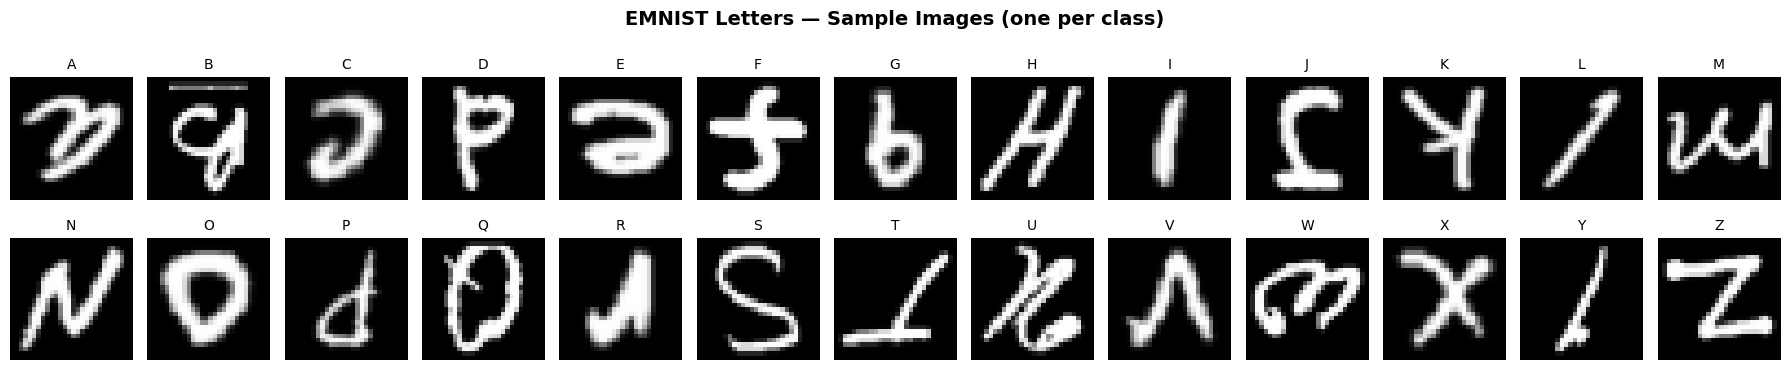

Sample image grid saved as 'sample_images.png'


In [8]:
def visualize_samples(images, labels, label_map, n_cols=13, n_rows=2):
    """Show one random sample per class."""
    unique_classes = sorted(np.unique(labels))
    n_show = min(len(unique_classes), n_cols * n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4))
    fig.suptitle('EMNIST Letters — Sample Images (one per class)', fontsize=14, fontweight='bold')

    for ax_idx, cls in enumerate(unique_classes[:n_show]):
        row, col = divmod(ax_idx, n_cols)
        idx = np.where(labels == cls)[0][0]
        axes[row, col].imshow(images[idx], cmap='gray')
        axes[row, col].set_title(label_map[cls], fontsize=10)
        axes[row, col].axis('off')

    # Hide any unused axes
    for ax_idx in range(n_show, n_rows * n_cols):
        row, col = divmod(ax_idx, n_cols)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Sample image grid saved as 'sample_images.png'")


visualize_samples(images, labels, LABEL_MAP)

### 1.2 Train / Test Split (80% / 20%)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    images, labels,
    test_size=TEST_SPLIT,
    random_state=RANDOM_STATE,
    stratify=labels
)

print(f"Training set : {X_train_raw.shape[0]} samples")
print(f"Testing  set : {X_test_raw.shape[0]} samples")

# Verify balance
unique, counts = np.unique(y_train, return_counts=True)
print(f"\nSamples per class in training set: {dict(zip([LABEL_MAP[u] for u in unique], counts))}")

Training set : 2080 samples
Testing  set : 520 samples

Samples per class in training set: {'A': np.int64(80), 'B': np.int64(80), 'C': np.int64(80), 'D': np.int64(80), 'E': np.int64(80), 'F': np.int64(80), 'G': np.int64(80), 'H': np.int64(80), 'I': np.int64(80), 'J': np.int64(80), 'K': np.int64(80), 'L': np.int64(80), 'M': np.int64(80), 'N': np.int64(80), 'O': np.int64(80), 'P': np.int64(80), 'Q': np.int64(80), 'R': np.int64(80), 'S': np.int64(80), 'T': np.int64(80), 'U': np.int64(80), 'V': np.int64(80), 'W': np.int64(80), 'X': np.int64(80), 'Y': np.int64(80), 'Z': np.int64(80)}


## 2. Feature Extraction — HOG (Histogram of Oriented Gradients)

In [ ]:
# ─────────────────────────────────────────────────────────────
# HOG PARAMETERS (customised from defaults)
#
#  orientations    : number of gradient orientation bins (default=9)
#  pixels_per_cell : size of each cell in pixels       (default=(8,8))
#  cells_per_block : cells per normalisation block     (default=(3,3))
# ─────────────────────────────────────────────────────────────
HOG_PARAMS = dict(
    orientations    = 12,
    pixels_per_cell = (4, 4),
    cells_per_block = (2, 2),
    block_norm      = 'L2-Hys',
    visualize       = False,
    transform_sqrt  = True
)

print("HOG parameters:")
for k, v in HOG_PARAMS.items():
    print(f"  {k}: {v}")

# Calculate expected feature vector length
_sample_feat = hog(images[0], **HOG_PARAMS)
print(f"\nFeature vector length per image: {len(_sample_feat)}")

HOG parameters:
  orientations: 12
  pixels_per_cell: (4, 4)
  cells_per_block: (2, 2)
  block_norm: L2-Hys
  visualize: False
  transform_sqrt: True

Feature vector length per image: 1728


In [11]:
def extract_hog_features(image_set, hog_params):
    """Extract HOG features for an array of grayscale images."""
    features = []
    for img in image_set:
        # Normalize pixel values to [0, 1] before HOG
        img_norm = img.astype(np.float32) / 255.0
        feat = hog(img_norm, **hog_params)
        features.append(feat)
    return np.array(features)


print("Extracting HOG features...")
t0 = time.time()
X_train = extract_hog_features(X_train_raw, HOG_PARAMS)
X_test  = extract_hog_features(X_test_raw,  HOG_PARAMS)
print(f"Done in {time.time() - t0:.1f}s")
print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

Extracting HOG features...
Done in 1.9s
X_train shape: (2080, 1728)
X_test  shape: (520, 1728)


### 2.1 Visualise HOG Features

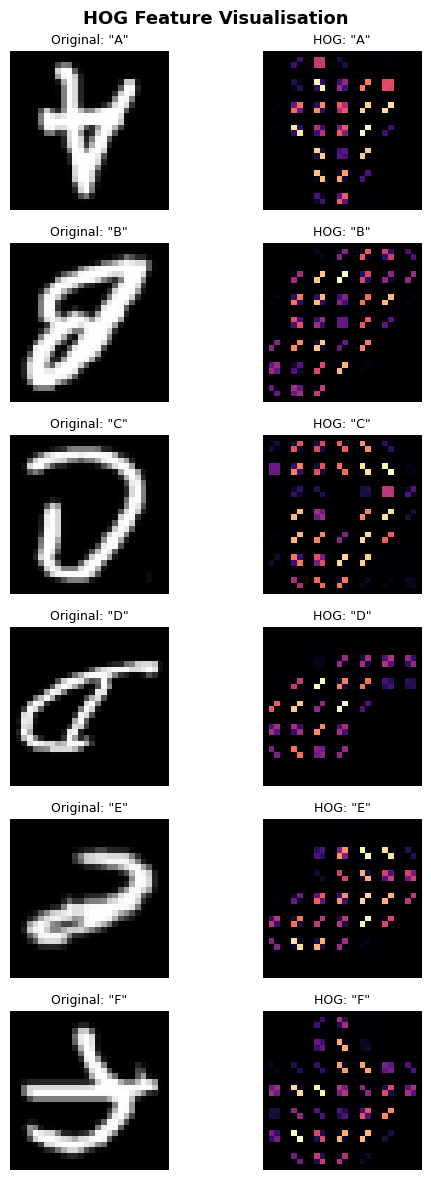

HOG visualisation saved as 'hog_visualization.png'


In [12]:
def visualize_hog(images, labels, label_map, hog_params, n_samples=6):
    """Show original images alongside their HOG visualisations."""
    # Pick one sample per class for the first n_samples classes
    chosen_indices = []
    unique_classes = sorted(np.unique(labels))[:n_samples]
    for cls in unique_classes:
        idx = np.where(labels == cls)[0][0]
        chosen_indices.append(idx)

    fig, axes = plt.subplots(n_samples, 2, figsize=(6, n_samples * 2))
    fig.suptitle('HOG Feature Visualisation', fontsize=13, fontweight='bold')

    vis_params = {**hog_params, 'visualize': True}

    for row, idx in enumerate(chosen_indices):
        img_norm = images[idx].astype(np.float32) / 255.0
        _, hog_image = hog(img_norm, **vis_params)
        hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

        letter = label_map[labels[idx]]
        axes[row, 0].imshow(images[idx], cmap='gray')
        axes[row, 0].set_title(f'Original: "{letter}"', fontsize=9)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(hog_image_rescaled, cmap='magma')
        axes[row, 1].set_title(f'HOG: "{letter}"', fontsize=9)
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.savefig('hog_visualization.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("HOG visualisation saved as 'hog_visualization.png'")


# Use training images / labels for visualisation
visualize_hog(X_train_raw, y_train, LABEL_MAP, HOG_PARAMS)

## 3. Classification — SVM with Grid Search

### 3.1 Grid Search to Find Best Hyperparameters

In [13]:
# ─────────────────────────────────────────────────────────────
# Grid Search parameter space
# Covering: kernel type, regularisation C, and gamma
# ─────────────────────────────────────────────────────────────
param_grid = [
    # RBF kernel
    {
        'kernel': ['rbf'],
        'C':      [0.1, 1, 10, 100],
        'gamma':  ['scale', 'auto', 0.001, 0.01]
    },
    # Linear kernel
    {
        'kernel': ['linear'],
        'C':      [0.1, 1, 10]
    },
    # Polynomial kernel
    {
        'kernel': ['poly'],
        'C':      [0.1, 1, 10],
        'gamma':  ['scale', 'auto'],
        'degree': [2, 3]
    }
]

print("Starting Grid Search (5-fold cross-validation)...")
print("This may take a few minutes.\n")

svm_base = SVC(random_state=RANDOM_STATE, class_weight='balanced')

grid_search = GridSearchCV(
    estimator  = svm_base,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'accuracy',
    n_jobs     = -1,        # use all CPU cores
    verbose    = 1,
    refit      = True       # retrain best model on full training set
)

t0 = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\nGrid Search completed in {elapsed:.1f}s")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV Score   : {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

Starting Grid Search (5-fold cross-validation)...
This may take a few minutes.

Fitting 5 folds for each of 31 candidates, totalling 155 fits

Grid Search completed in 189.2s
Best Parameters : {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
Best CV Score   : 0.8322 (83.22%)


In [14]:
# Best estimator is automatically fitted on full training data (refit=True)
best_svm = grid_search.best_estimator_
print("Best SVM model:")
print(best_svm)

Best SVM model:
SVC(C=1, class_weight='balanced', degree=2, kernel='poly', random_state=42)


### 3.2 Grid Search Results Visualisation

In [15]:
results_df = pd.DataFrame(grid_search.cv_results_)
top_results = (
    results_df[['param_kernel', 'param_C', 'param_gamma', 'param_degree',
                'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
)
print("Top 10 Grid Search Results:")
print(top_results.to_string(index=False))

Top 10 Grid Search Results:
param_kernel  param_C param_gamma  param_degree  mean_test_score  std_test_score  rank_test_score
        poly      1.0       scale           2.0         0.832212        0.021198                1
        poly     10.0       scale           2.0         0.826923        0.016515                2
        poly     10.0       scale           3.0         0.826442        0.027086                3
         rbf    100.0       scale           NaN         0.825962        0.023533                4
         rbf     10.0       scale           NaN         0.825962        0.023533                4
        poly      1.0       scale           3.0         0.825000        0.028540                6
         rbf     10.0        0.01           NaN         0.820192        0.018458                7
         rbf    100.0        0.01           NaN         0.820192        0.017886                7
         rbf      1.0       scale           NaN         0.817308        0.031599          

## 4. Evaluation

### 4.1 Training Set Performance

In [16]:
def compute_metrics(y_true, y_pred, dataset_name='Dataset'):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n{'═'*45}")
    print(f"  {dataset_name} Performance")
    print(f"{'═'*45}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}  ({prec*100:.2f}%)")
    print(f"  Recall    : {rec:.4f}  ({rec*100:.2f}%)")
    print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
    print(f"{'═'*45}")
    return acc, prec, rec, f1


# Training predictions
y_train_pred = best_svm.predict(X_train)
train_metrics = compute_metrics(y_train, y_train_pred, 'Training Set (80%)')


═════════════════════════════════════════════
  Training Set (80%) Performance
═════════════════════════════════════════════
  Accuracy  : 0.9899  (98.99%)
  Precision : 0.9901  (99.01%)
  Recall    : 0.9899  (98.99%)
  F1-Score  : 0.9900  (99.00%)
═════════════════════════════════════════════


### 4.2 Test Set Performance

In [17]:
# Test predictions
y_test_pred = best_svm.predict(X_test)
test_metrics = compute_metrics(y_test, y_test_pred, 'Test Set (20%)')


═════════════════════════════════════════════
  Test Set (20%) Performance
═════════════════════════════════════════════
  Accuracy  : 0.8654  (86.54%)
  Precision : 0.8707  (87.07%)
  Recall    : 0.8654  (86.54%)
  F1-Score  : 0.8646  (86.46%)
═════════════════════════════════════════════


### 4.3 Per-Class Classification Report

In [18]:
target_names = [LABEL_MAP[i] for i in sorted(np.unique(y_test))]
print("\nDetailed Classification Report (Test Set):\n")
print(classification_report(
    y_test, y_test_pred,
    target_names=target_names,
    zero_division=0
))


Detailed Classification Report (Test Set):

              precision    recall  f1-score   support

           A       0.65      0.85      0.74        20
           B       0.89      0.85      0.87        20
           C       0.90      0.95      0.93        20
           D       0.83      1.00      0.91        20
           E       1.00      0.95      0.97        20
           F       0.90      0.95      0.93        20
           G       0.77      0.50      0.61        20
           H       0.75      0.90      0.82        20
           I       0.73      0.80      0.76        20
           J       0.88      0.75      0.81        20
           K       0.90      0.90      0.90        20
           L       0.65      0.75      0.70        20
           M       0.95      0.90      0.92        20
           N       0.95      0.95      0.95        20
           O       0.95      1.00      0.98        20
           P       0.90      0.90      0.90        20
           Q       0.70      0.70   

### 4.4 Metrics Comparison Chart

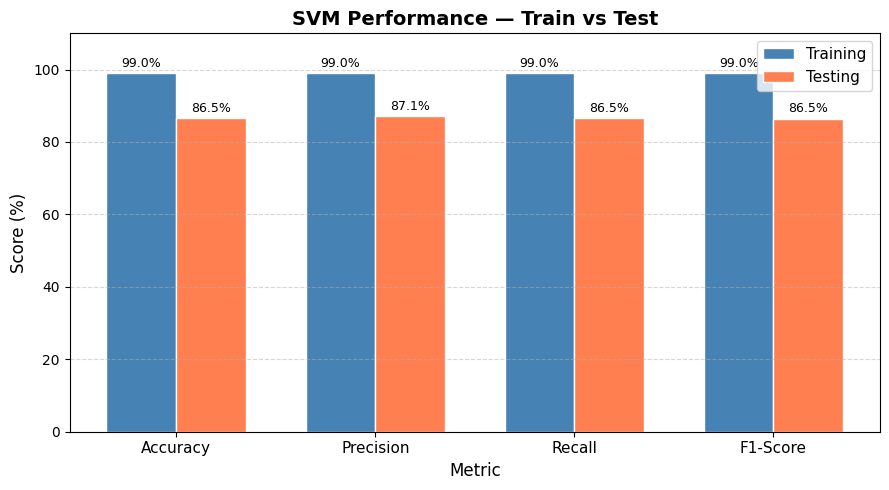

Metrics chart saved as 'metrics_comparison.png'


In [19]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_vals   = list(train_metrics)
test_vals    = list(test_metrics)

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_train = ax.bar(x - width/2, [v*100 for v in train_vals], width,
                    label='Training', color='steelblue', edgecolor='white')
bars_test  = ax.bar(x + width/2, [v*100 for v in test_vals],  width,
                    label='Testing',  color='coral',     edgecolor='white')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('SVM Performance — Train vs Test', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Metrics chart saved as 'metrics_comparison.png'")

### 4.5 Confusion Matrix

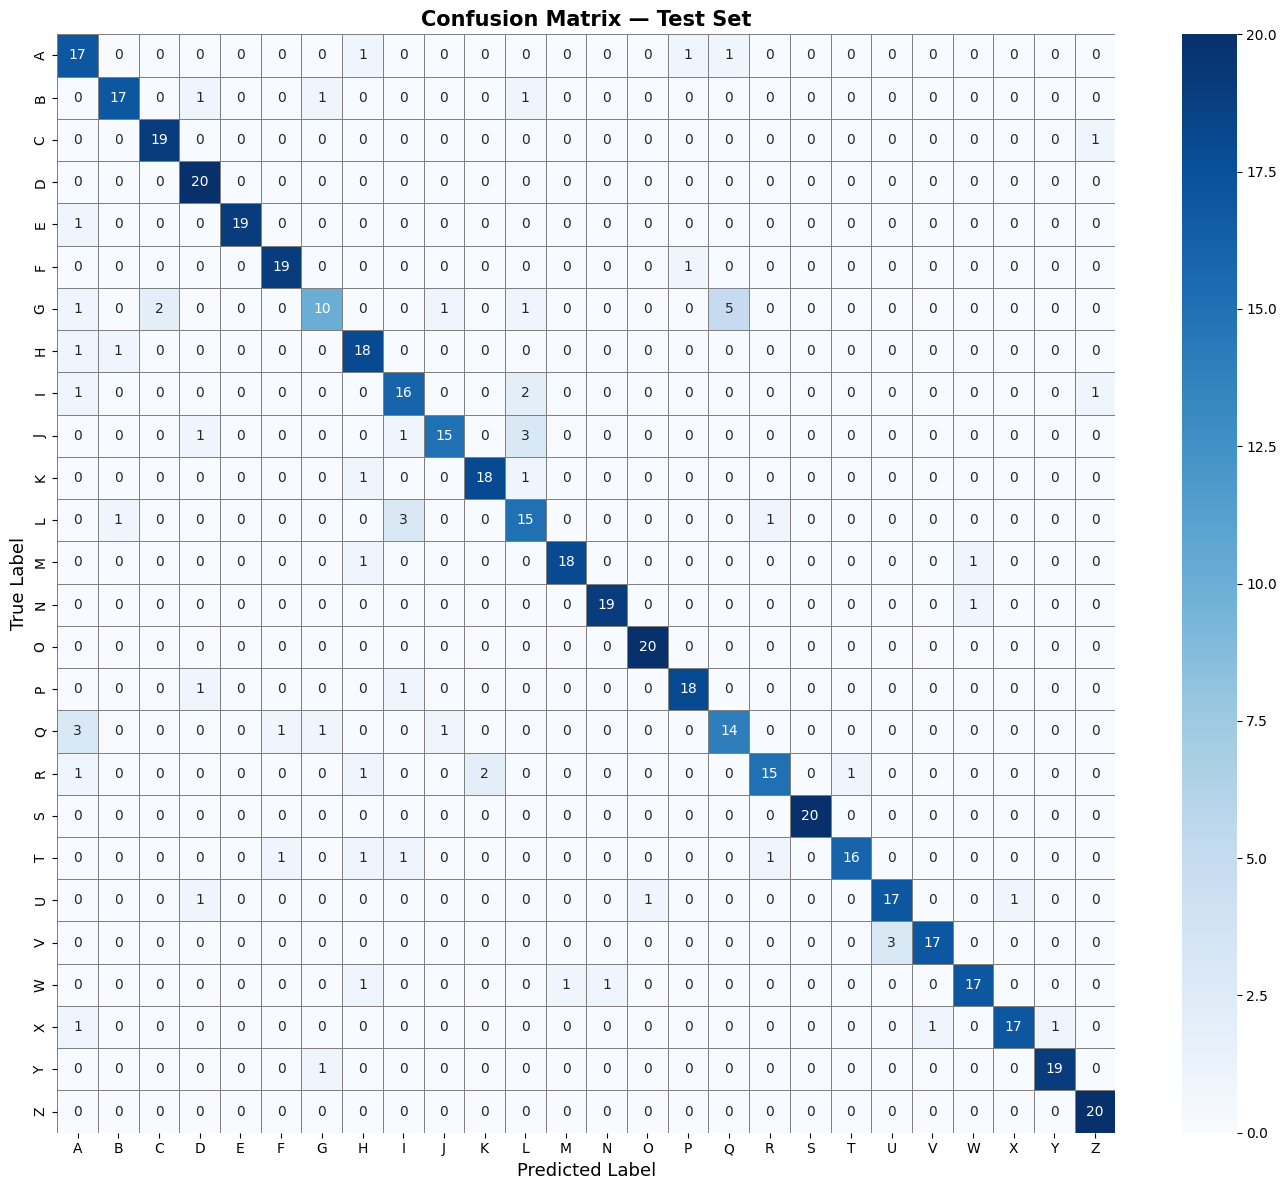

Confusion matrix saved as 'confusion_matrix.png'


In [20]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    linewidths=0.5, linecolor='gray',
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('Confusion Matrix — Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")

### 4.6 Per-Class F1 Score Bar Chart

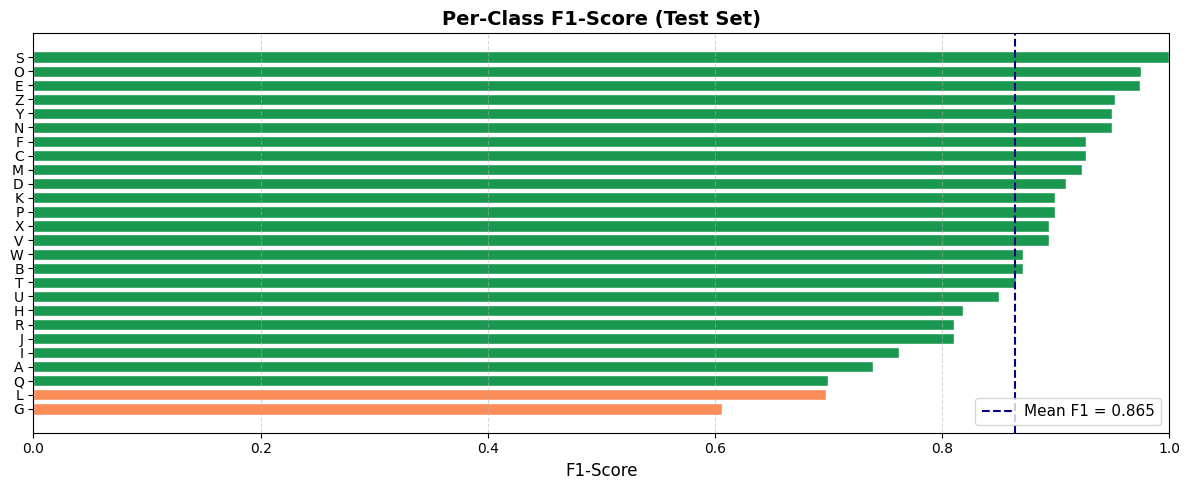

Per-class F1 chart saved as 'per_class_f1.png'


In [21]:
f1_per_class = f1_score(y_test, y_test_pred, average=None, zero_division=0)
sorted_idx   = np.argsort(f1_per_class)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d73027' if v < 0.5 else '#fc8d59' if v < 0.7 else '#1a9850'
          for v in f1_per_class[sorted_idx]]
ax.barh([target_names[i] for i in sorted_idx], f1_per_class[sorted_idx],
        color=colors, edgecolor='white')
ax.axvline(x=np.mean(f1_per_class), color='navy', linestyle='--',
           linewidth=1.5, label=f'Mean F1 = {np.mean(f1_per_class):.3f}')
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Per-Class F1-Score (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()
print("Per-class F1 chart saved as 'per_class_f1.png'")

### 4.7 Sample Predictions

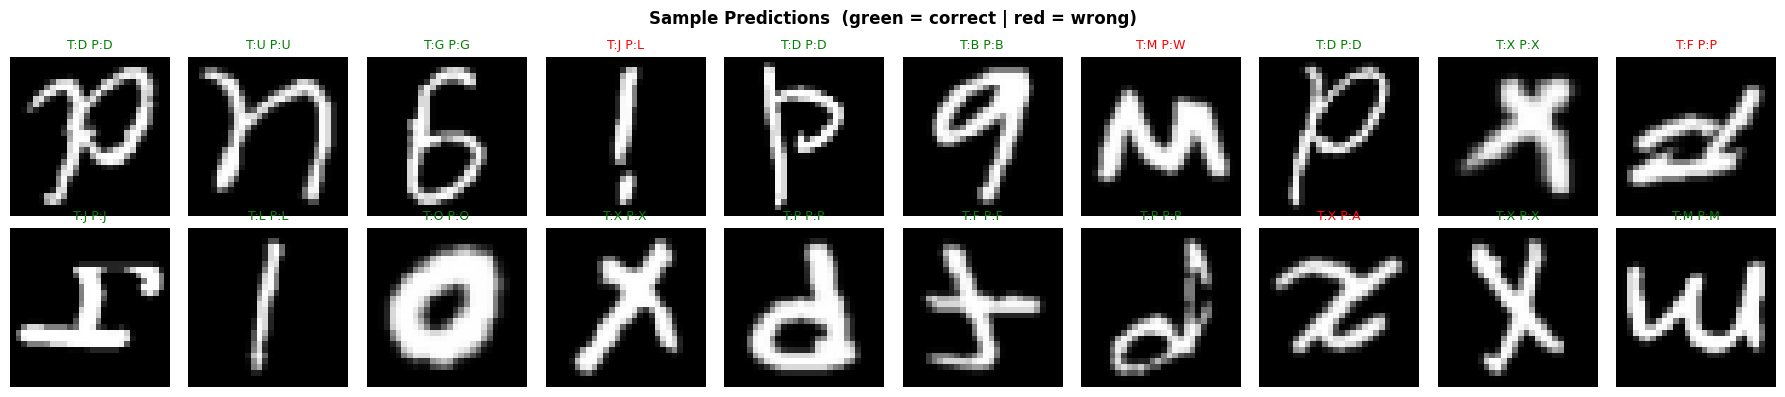

Sample predictions saved as 'sample_predictions.png'


In [22]:
def show_predictions(images, y_true, y_pred, label_map, n=20):
    fig, axes = plt.subplots(2, 10, figsize=(18, 4))
    fig.suptitle('Sample Predictions  (green = correct | red = wrong)',
                 fontsize=12, fontweight='bold')
    indices = np.random.choice(len(images), n, replace=False)
    for ax, idx in zip(axes.flat, indices):
        ax.imshow(images[idx], cmap='gray')
        true_lbl = label_map[y_true[idx]]
        pred_lbl = label_map[y_pred[idx]]
        color = 'green' if true_lbl == pred_lbl else 'red'
        ax.set_title(f'T:{true_lbl} P:{pred_lbl}', fontsize=9, color=color)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Sample predictions saved as 'sample_predictions.png'")


show_predictions(X_test_raw, y_test, y_test_pred, LABEL_MAP)

## 5. Summary

In [23]:
print("=" * 55)
print("  EXPERIMENT SUMMARY")
print("=" * 55)
print(f"  Dataset        : EMNIST Letters")
print(f"  Total Samples  : {len(images)} (26 classes × 100)")
print(f"  Train / Test   : {X_train.shape[0]} / {X_test.shape[0]}")
print()
print("  HOG Parameters:")
for k, v in HOG_PARAMS.items():
    if k != 'visualize':
        print(f"    {k:20s}: {v}")
print(f"  Feature Dim    : {X_train.shape[1]}")
print()
print("  Best SVM Parameters:")
for k, v in grid_search.best_params_.items():
    print(f"    {k:20s}: {v}")
print()
print(f"  {'Metric':<15} {'Train':>10} {'Test':>10}")
print(f"  {'-'*38}")
for name, tr, te in zip(metric_names, train_metrics, test_metrics):
    print(f"  {name:<15} {tr*100:>9.2f}% {te*100:>9.2f}%")
print("=" * 55)

  EXPERIMENT SUMMARY
  Dataset        : EMNIST Letters
  Total Samples  : 2600 (26 classes × 100)
  Train / Test   : 2080 / 520

  HOG Parameters:
    orientations        : 12
    pixels_per_cell     : (4, 4)
    cells_per_block     : (2, 2)
    block_norm          : L2-Hys
    transform_sqrt      : True
  Feature Dim    : 1728

  Best SVM Parameters:
    C                   : 1
    degree              : 2
    gamma               : scale
    kernel              : poly

  Metric               Train       Test
  --------------------------------------
  Accuracy            98.99%     86.54%
  Precision           99.01%     87.07%
  Recall              98.99%     86.54%
  F1-Score            99.00%     86.46%
